# **Student score based on habits**
(prediction model)

### Importing imp libraries 

In [59]:
# Imp libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Importing imp libraries/ functions form sklearn 
from sklearn.model_selection import train_test_split , GridSearchCV     # for spliting the data into training and spliting / and for tuning the data
from sklearn.preprocessing import LabelEncoder                          # Encoding the data 
from sklearn.metrics import mean_squared_error , r2_score               # for accuracy analysis that is model evaluation
from sklearn.linear_model import LinearRegression , Ridge               # For model selection
from sklearn.ensemble import RandomForestRegressor                      
from sklearn.tree import DecisionTreeRegressor, BaseDecisionTree

In [3]:
# importing the data as pandas dataframe 

df = pd.read_csv('D:\Robotics\Machine Learning Projects\Exam score prediction\From YT\src\data\student_habits_performance.csv')

### Analysing the data

In [4]:
#Checking if the data is added properly
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
# Checking the info of the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [7]:
df.shape

(1000, 16)

### checking the statistical value of the data 

In [8]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


## Checking for null values 

In [9]:
df.isna().sum().sum()

np.int64(91)

In [10]:
df= df.dropna()

What we did here is , we have removed all the rows where any null value is present so our data will be like data in which all the iterations have all the values filled properly 

Reason for doing that is : Here in this project we are finding the correlation between the habits and academic performance so we dont want any data to miss anything , that will hamper the correlation equation 

In [11]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

## Checking for duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1999,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [15]:
df.describe(include="object").columns


Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [19]:
# Get data as a categorical column
categorical_cols =  [ 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation']

In [20]:
# Writing a function to see the values of the columns

for col in categorical_cols :
    print(f" value for the {col} : \n {df[col].value_counts()}")

 value for the gender : 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
 value for the part_time_job : 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
 value for the diet_quality : 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
 value for the parental_education_level : 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
 value for the internet_quality : 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
 value for the extracurricular_participation : 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


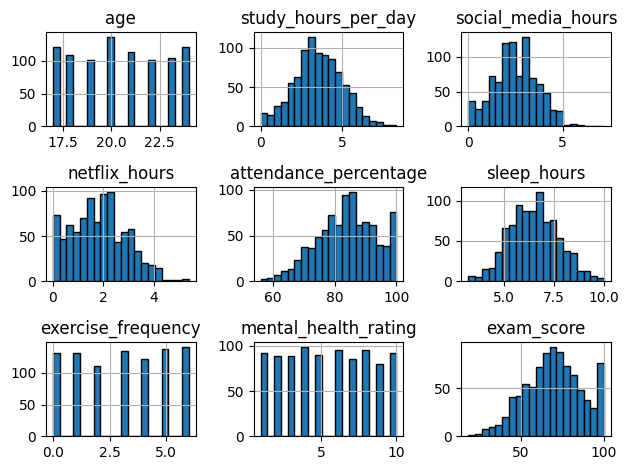

In [21]:
df.hist(bins=20 , edgecolor = 'black')
plt.tight_layout()
plt.show()

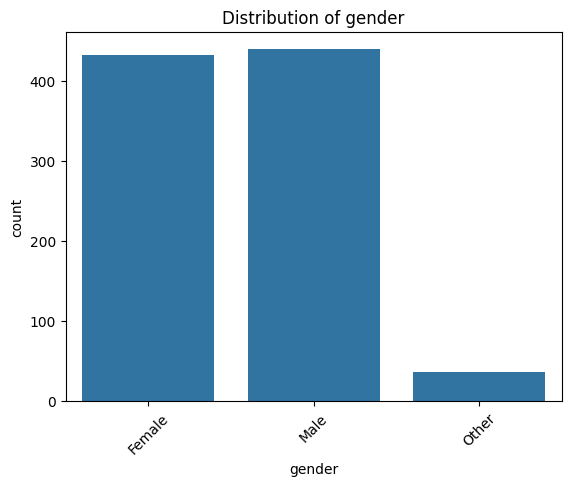

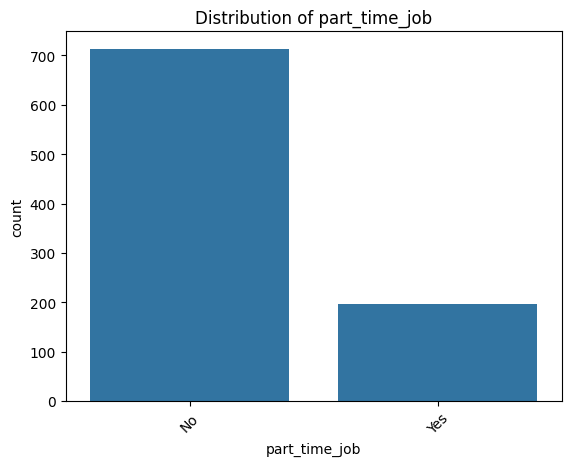

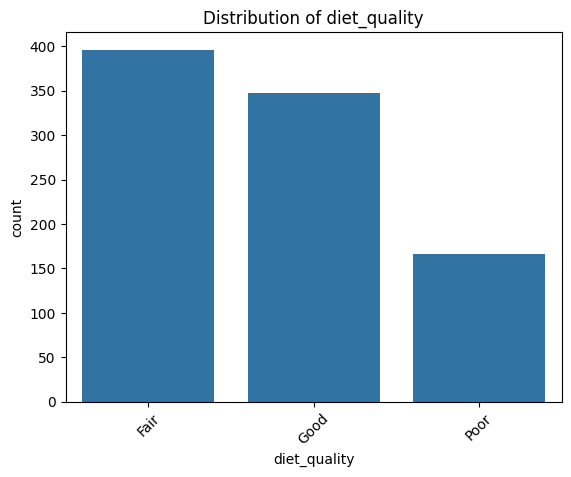

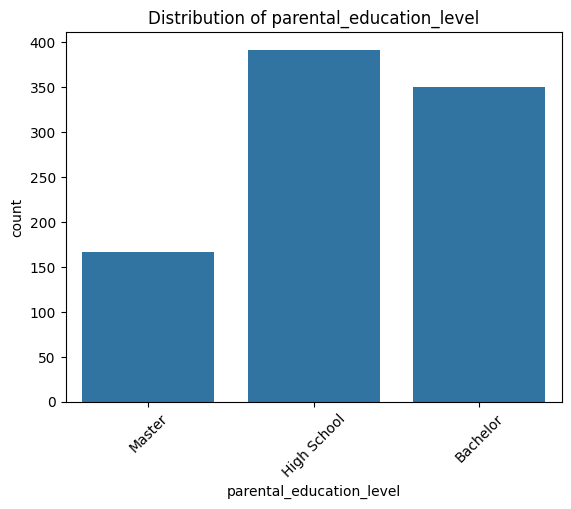

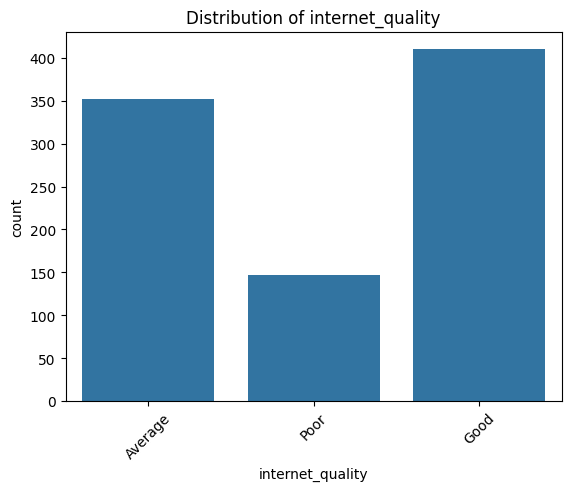

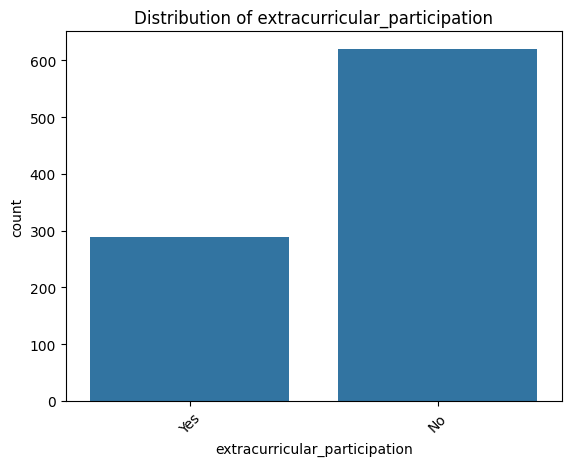

In [24]:
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    plt.show()

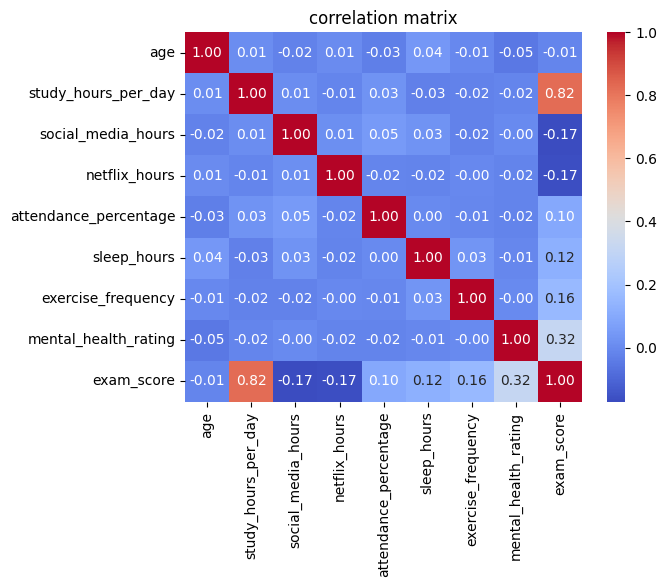

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='coolwarm',fmt=".2f")
plt.title("correlation matrix")
plt.show()

In [26]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [27]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

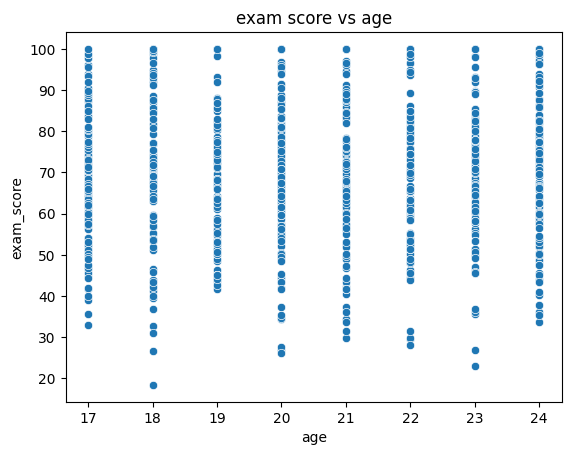

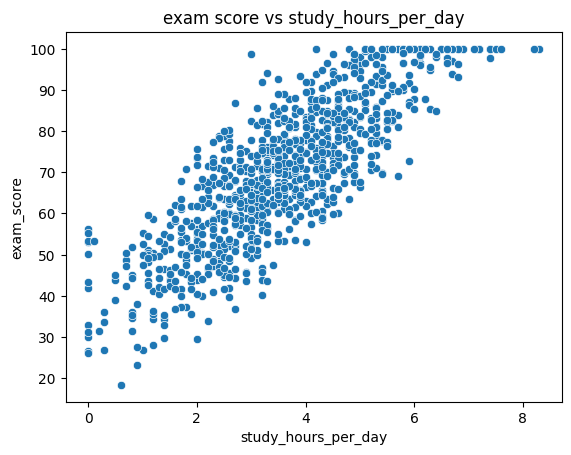

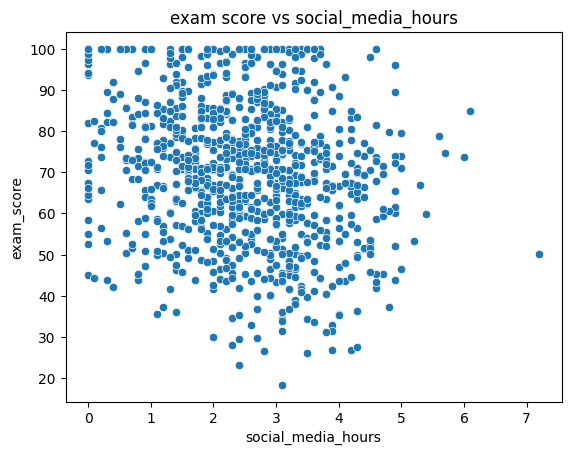

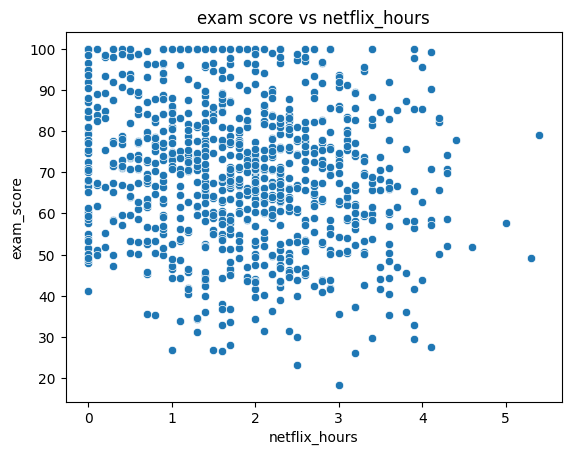

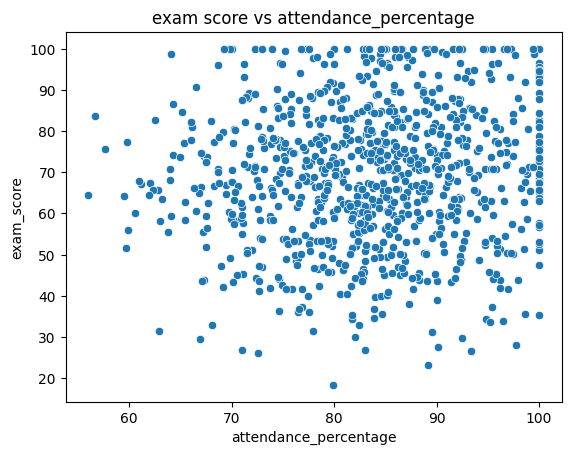

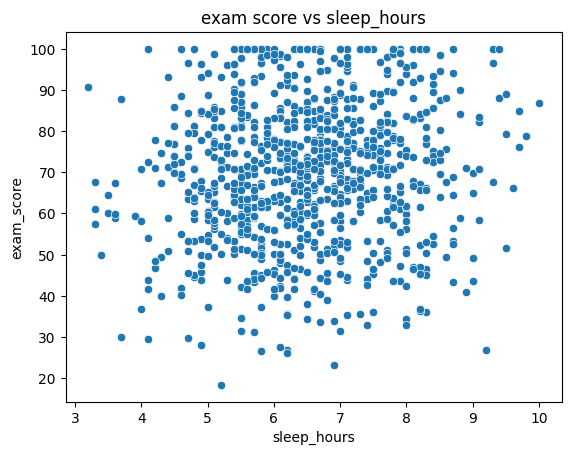

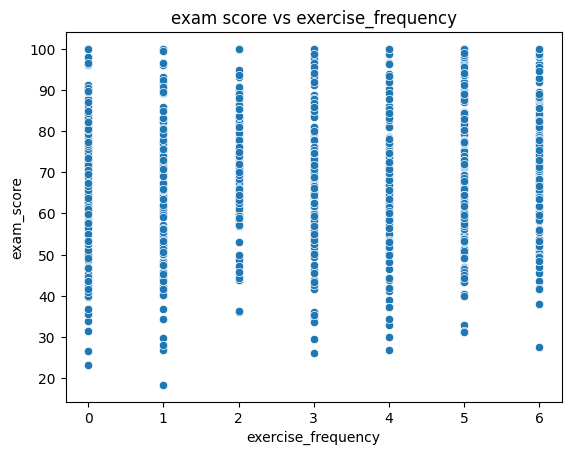

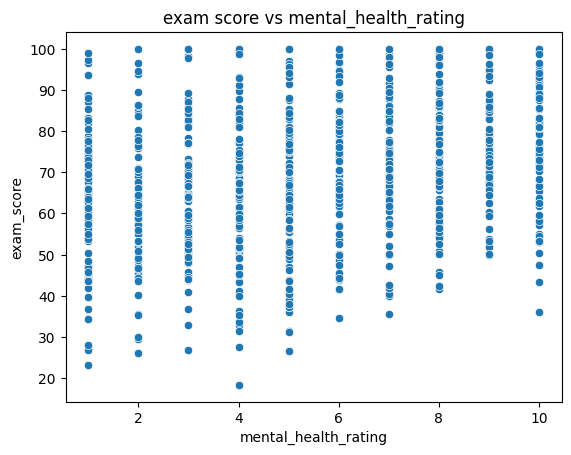

In [28]:
for feature in num_features:
    sns.scatterplot(data=df , x=feature, y="exam_score")
    plt.title(f'exam score vs {feature}')
    plt.show()

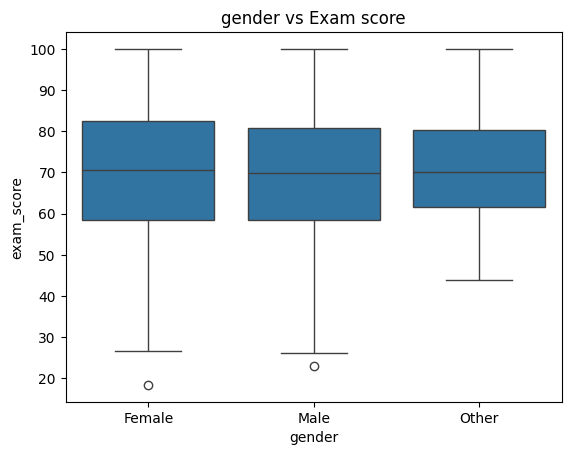

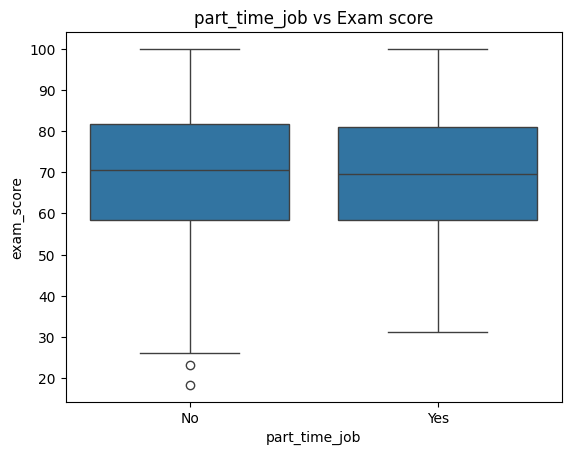

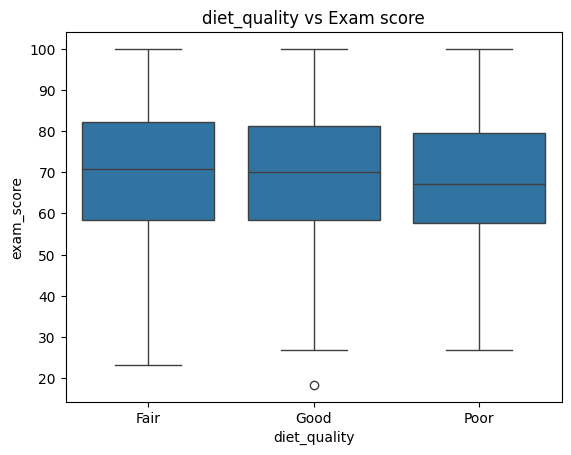

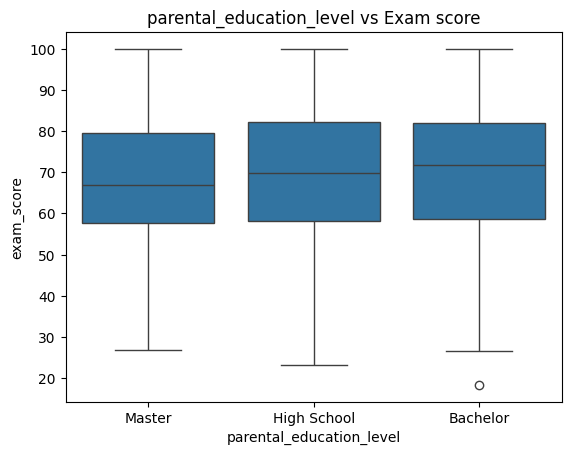

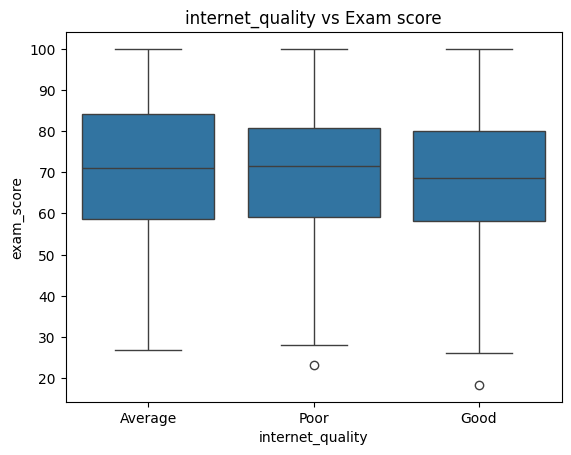

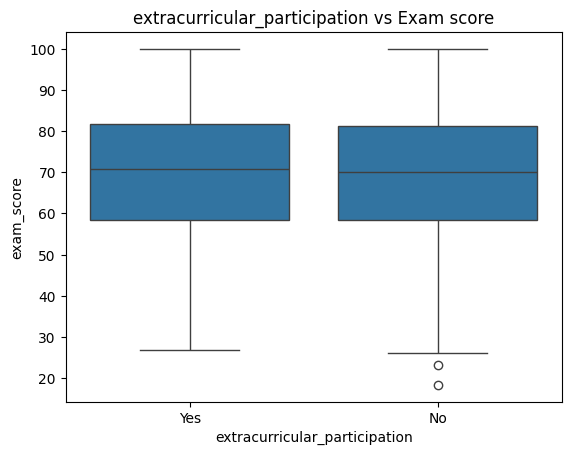

In [29]:
for col in categorical_cols :
    sns.boxplot(data=df , x=col , y = "exam_score")
    plt.title(f"{col} vs Exam score")
    plt.show()

# Model Training starts from here

In [30]:
# selecting the features for trainng the data 

df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [32]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [40]:
# we will selecto the data which contribute more to the score .. we have decided that when analysing the data visually 

feature = ["study_hours_per_day","attendance_percentage","mental_health_rating","part_time_job","sleep_hours"]

## Selecting the target

In [38]:
target = "exam_score"

In [41]:
df_model = df[feature + [target]].copy()

Above we have made a new dataframe with approprite parameters to further use them accordingly , 

In [43]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,part_time_job,sleep_hours,exam_score
0,0.0,85.0,8,No,8.0,56.2
1,6.9,97.3,8,No,4.6,100.0
2,1.4,94.8,1,No,8.0,34.3
3,1.0,71.0,1,No,9.2,26.8
4,5.0,90.9,1,No,4.9,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,No,7.5,76.1
996,2.9,86.0,6,Yes,6.8,65.9
997,3.0,61.9,9,No,6.5,64.4
998,5.4,100.0,1,Yes,7.6,69.7


In [47]:
# initialising the label encoder

le = LabelEncoder()

In [52]:
# testing the encoder 
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

In [53]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,part_time_job,sleep_hours,exam_score
0,0.0,85.0,8,0,8.0,56.2
1,6.9,97.3,8,0,4.6,100.0
2,1.4,94.8,1,0,8.0,34.3
3,1.0,71.0,1,0,9.2,26.8
4,5.0,90.9,1,0,4.9,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,0,7.5,76.1
996,2.9,86.0,6,1,6.8,65.9
997,3.0,61.9,9,0,6.5,64.4
998,5.4,100.0,1,1,7.6,69.7


In [49]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,part_time_job,sleep_hours,exam_score
0,0.0,85.0,8,No,8.0,56.2
1,6.9,97.3,8,No,4.6,100.0
2,1.4,94.8,1,No,8.0,34.3
3,1.0,71.0,1,No,9.2,26.8
4,5.0,90.9,1,No,4.9,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,No,7.5,76.1
996,2.9,86.0,6,Yes,6.8,65.9
997,3.0,61.9,9,No,6.5,64.4
998,5.4,100.0,1,Yes,7.6,69.7


In [85]:
df_model.columns

Index(['study_hours_per_day', 'attendance_percentage', 'mental_health_rating',
       'part_time_job', 'sleep_hours', 'exam_score'],
      dtype='object')

## Spliting the df to X and Y

In [54]:
x= df_model[feature]

In [55]:
y= df_model[target]

In [56]:
X_train , X_test , Y_train , Y_test = train_test_split(x,y,test_size=0.2)

In [57]:
len(X_test)

182

In [58]:
len(X_train)

727

In [67]:
# Initialising the models to use 
models = {
    "LinearRegression":{
        "model": LinearRegression(),
        "params":{}

    },


    "DecisionTree":
    {
    "model": DecisionTreeRegressor(),
    "params": {"max_depth":[3,5,10],"min_samples_split":[2,5]}
    
    },
    "RandomForest":{
        "model":RandomForestRegressor(),
        "params":{"n_estimators" : [50,100],"max_depth":[5,10]}
    }
}

In [61]:
best_models = []

In [68]:
for name , config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(config["model"],config["params"],cv=5,scoring="neg_mean_squared_error")
    grid.fit(X_train , Y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test,y_pred))
    r2 = r2_score(Y_test,y_pred)


    best_models.append({
        "model":name,
        "best-params":grid.best_params_,
        "rmse":rmse,
        "r2":r2


    })

Training LinearRegression
Training DecisionTree
Training RandomForest


In [71]:
best_models

[{'model': 'LinearRegression',
  'best-params': {},
  'rmse': np.float64(7.023917177449916),
  'r2': 0.8280282918716166},
 {'model': 'LinearRegression',
  'best-params': {},
  'rmse': np.float64(7.023917177449916),
  'r2': 0.8280282918716166},
 {'model': 'DecisionTree',
  'best-params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(8.638524995507504),
  'r2': 0.7398777933614293},
 {'model': 'LinearRegression',
  'best-params': {},
  'rmse': np.float64(7.023917177449916),
  'r2': 0.8280282918716166},
 {'model': 'DecisionTree',
  'best-params': {'max_depth': 5, 'min_samples_split': 2},
  'rmse': np.float64(8.638524995507504),
  'r2': 0.7398777933614293},
 {'model': 'RandomForest',
  'best-params': {'max_depth': 5, 'n_estimators': 50},
  'rmse': np.float64(8.118177119062537),
  'r2': 0.770271283716567}]

In [69]:
results_df = pd.DataFrame(best_models)

In [70]:
results_df.sort_values(by="rmse")

,model,best-params,rmse,r2
0,LinearRegression,{},7.023917,0.828028
1,LinearRegression,{},7.023917,0.828028
3,LinearRegression,{},7.023917,0.828028
5,RandomForest,"{'max_depth': 5, 'n_estimators': 50}",8.118177,0.770271
2,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.638525,0.739878
4,DecisionTree,"{'max_depth': 5, 'min_samples_split': 2}",8.638525,0.739878


In [73]:
import joblib

best_row = results_df.sort_values(by="rmse").iloc[0]

In [74]:
best_row

model          LinearRegression
best-params                  {}
rmse                   7.023917
r2                     0.828028
Name: 0, dtype: object

In [75]:
best_model_name = best_row["model"]

In [76]:
best_model_name

'LinearRegression'

In [78]:
best_model_config =models[best_model_name]

In [79]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [80]:
final_model = best_model_config["model"]

In [86]:
final_model.fit(x,y)

LinearRegression()

In [87]:
final_model.predict(X_test)

array([ 78.07562614,  85.35394269,  79.77697389,  52.00021266,
        61.46176878,  78.93711347,  63.09414629,  84.62669148,
        71.16711953,  60.44639729,  78.49984679,  79.32808448,
        80.33218451,  86.38678834,  52.63399438,  83.76282292,
        80.46594508,  62.66539553,  47.10026421, 100.85164657,
        80.46322951,  70.32196933,  74.66430702,  52.84828921,
        73.63843002,  56.40314637,  59.86149389,  86.75373513,
        80.25838196,  85.23484959,  81.55564529,  63.24170396,
        60.61304698,  38.09300671,  59.80546684,  56.84795774,
        81.14151653,  45.36227919,  74.93620762,  76.75958523,
        84.75734186,  62.717919  ,  71.80449683,  65.85386755,
        86.04159457,  63.58381267,  84.7271526 ,  84.00104813,
        54.52840609,  50.37910151,  73.79670885,  55.5393701 ,
        83.44563148,  54.28921371,  70.53217871,  65.81297953,
        75.85209083,  87.18702105,  90.63779187, 102.62470515,
        83.02517528,  81.50258474,  70.58020241,  58.28

In [88]:
joblib.dump(final_model,"model.plk")

['model.plk']

In [89]:
joblib.load("model.plk").predict(X_test)

array([ 78.07562614,  85.35394269,  79.77697389,  52.00021266,
        61.46176878,  78.93711347,  63.09414629,  84.62669148,
        71.16711953,  60.44639729,  78.49984679,  79.32808448,
        80.33218451,  86.38678834,  52.63399438,  83.76282292,
        80.46594508,  62.66539553,  47.10026421, 100.85164657,
        80.46322951,  70.32196933,  74.66430702,  52.84828921,
        73.63843002,  56.40314637,  59.86149389,  86.75373513,
        80.25838196,  85.23484959,  81.55564529,  63.24170396,
        60.61304698,  38.09300671,  59.80546684,  56.84795774,
        81.14151653,  45.36227919,  74.93620762,  76.75958523,
        84.75734186,  62.717919  ,  71.80449683,  65.85386755,
        86.04159457,  63.58381267,  84.7271526 ,  84.00104813,
        54.52840609,  50.37910151,  73.79670885,  55.5393701 ,
        83.44563148,  54.28921371,  70.53217871,  65.81297953,
        75.85209083,  87.18702105,  90.63779187, 102.62470515,
        83.02517528,  81.50258474,  70.58020241,  58.28